Sepet analizi için veri hazırlanıyor...


C:\Users\uygrg\AppData\Local\Temp\ipykernel_4632\3663485919.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)


✅ Sepet Matrisi Hazır! Boyut: (36311, 12)

AutoML Başlıyor: En uygun destek (support) değeri aranıyor...
✅ Support=0.005 için 4 adet anlamlı kural bulundu!

🏆 EN GÜÇLÜ 5 KURAL (Seçilen Support: 0.005)
------------------------------------------------------------
🛒 EĞER [İÇECEK] ALINIRSA -> [SÜT KAHVALTILIK] ALINIYOR
   (Güven: %20.2, Lift: 1.15 kat)

🛒 EĞER [SÜT KAHVALTILIK] ALINIRSA -> [İÇECEK] ALINIYOR
   (Güven: %3.5, Lift: 1.15 kat)

🛒 EĞER [SÜT KAHVALTILIK] ALINIRSA -> [GIDA] ALINIYOR
   (Güven: %47.5, Lift: 1.11 kat)

🛒 EĞER [GIDA] ALINIRSA -> [SÜT KAHVALTILIK] ALINIYOR
   (Güven: %1.4, Lift: 1.11 kat)



C:\Users\uygrg\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\uygrg\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


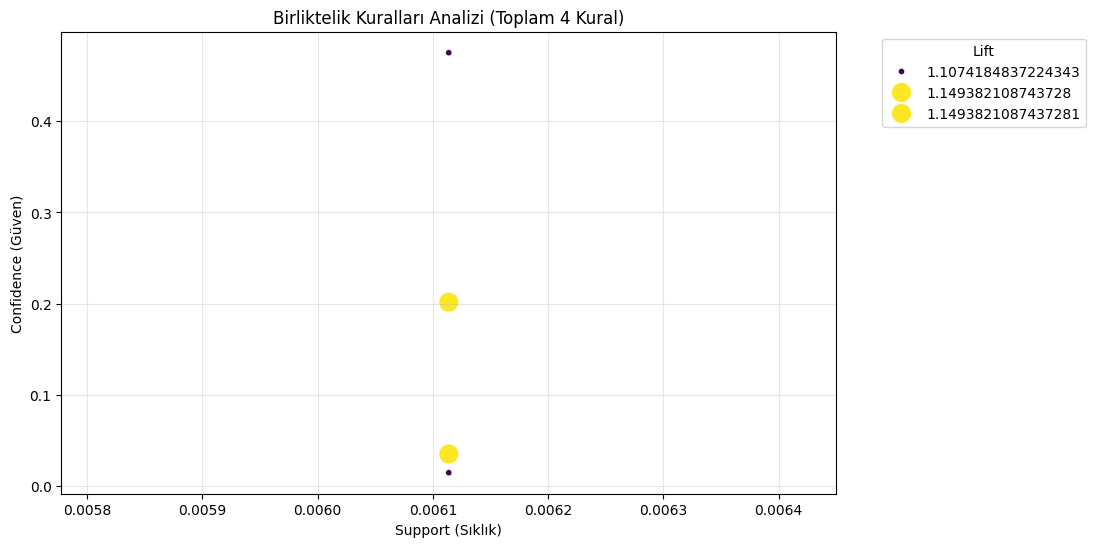

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from mlxtend.frequent_patterns import apriori, association_rules

# --- 1. VERİ KONTROLÜ ---
if 'df' not in locals():
    print("Veri yükleniyor...")
    olasi_yollar = ['MarketSales.xlsx', 'MarketSales.csv', '../MarketSales.xlsx', '../MarketSales.csv']
    for yol in olasi_yollar:
        if os.path.exists(yol):
            try:
                df = pd.read_excel(yol) if yol.endswith('xlsx') else pd.read_csv(yol)
                break
            except: continue

# Sütun isimlerini temizle
df.columns = df.columns.str.strip()

# --- 2. VERİ HAZIRLIĞI ---
print("Sepet analizi için veri hazırlanıyor...")

target_cols = ['FICHENO', 'CATEGORY_NAME1']
if 'FICHENO' not in df.columns: 
    if 'FİSNO' in df.columns: target_cols = ['FİSNO', 'CATEGORY_NAME1']

# Veriyi örnekle
df_rules = df[target_cols].dropna().sample(n=50000, random_state=42)

# Sepet Matrisi
basket = (df_rules.groupby(target_cols)[target_cols[1]]
          .count().unstack().reset_index().fillna(0)
          .set_index(target_cols[0]))

# 1-0 Dönüşümü
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
print(f"✅ Sepet Matrisi Hazır! Boyut: {basket_sets.shape}")

# --- 3. AUTOML: KURALLARI ARAMA ---
print("\nAutoML Başlıyor: En uygun destek (support) değeri aranıyor...")

best_rules = pd.DataFrame()
best_sup = 0
support_trials = [0.01, 0.005, 0.001, 0.0001] # Denenecek değerler

for sup in support_trials:
    frequent_items = apriori(basket_sets, min_support=sup, use_colnames=True)
    
    if len(frequent_items) > 0:
        rules = association_rules(frequent_items, metric="lift", min_threshold=1.01)
        if len(rules) > 0:
            print(f"✅ Support={sup} için {len(rules)} adet anlamlı kural bulundu!")
            best_rules = rules
            best_sup = sup
            break 

# --- 4. SONUÇLARI GÖSTERME VE GRAFİK ---
if not best_rules.empty:
    print(f"\n🏆 EN GÜÇLÜ 5 KURAL (Seçilen Support: {best_sup})")
    print("-" * 60)
    
    top_rules = best_rules.sort_values(by='lift', ascending=False).head(5)
    
    for index, row in top_rules.iterrows():
        ant = list(row['antecedents'])[0]
        cons = list(row['consequents'])[0]
        # HATA BURADAYDI, DÜZELTİLDİ: {consequents} -> {cons}
        print(f"🛒 EĞER [{ant}] ALINIRSA -> [{cons}] ALINIYOR")
        print(f"   (Güven: %{row['confidence']*100:.1f}, Lift: {row['lift']:.2f} kat)\n")
    
    # GRAFİK
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                    data=best_rules, palette="viridis", sizes=(20, 200))
    plt.title(f'Birliktelik Kuralları Analizi (Toplam {len(best_rules)} Kural)')
    plt.xlabel('Support (Sıklık)')
    plt.ylabel('Confidence (Güven)')
    plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("❌ Kural bulunamadı.")